<a href="https://colab.research.google.com/github/Ankit-K-Sharma7/Spam_Detection_Using_NLP/blob/main/Spam_Detection_NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***TASK 1 - LOAD & EXPLORE THE DATASET***

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('spam.csv')

In [ ]:
print(df.head())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
print(df.shape)

(5572, 2)


In [ ]:
print(df["Category"].value_counts())

Category
ham     4825
spam     747
Name: count, dtype: int64


***TASK 2 - VISUALIZE THE DATASET***

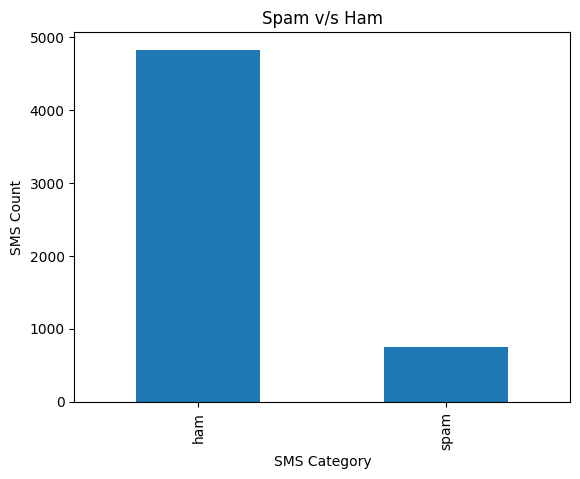

In [ ]:
counts = df["Category"].value_counts()
counts.plot(kind="bar")
plt.title("Spam v/s Ham")
plt.xlabel("SMS Category")
plt.ylabel("SMS Count")
plt.show()

***TASK 3 - PREPARE THE DATA***

In [ ]:
df["Category"] = df["Category"].map({"ham": 0, "spam": 1})

In [ ]:
x = df["Message"]
y = df["Category"]

***TASK 4 - SPLIT THE DATASET***

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

***TASK 5 - CONVERT TEXT INTO NUMBERS***

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words="english")
x_train_vector = vectorizer.fit_transform(x_train)
x_test_vector = vectorizer.transform(x_test)

***TASK 6 - TRAIN A MACHINE LEARNING MODEL***

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train_vector, y_train)

LogisticRegression(max_iter=1000)

***TASK 7 - MAKE PREDICTIONS***

In [ ]:
predictions = model.predict(x_test_vector)

***TASK 8 - EVALUATE THE MODEL***

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9838565022421525


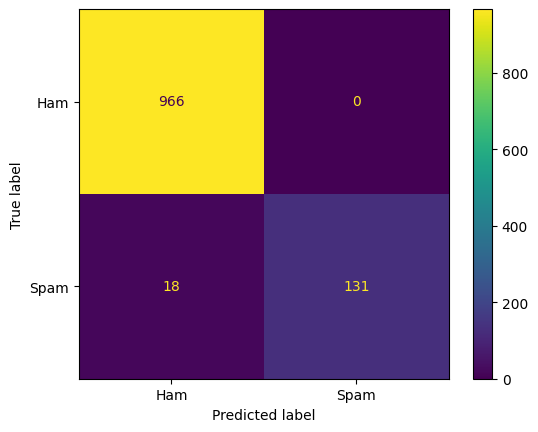

Confusion Matrix: 
 [[966   0]
 [ 18 131]]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion = confusion_matrix(y_test, predictions)
display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Ham","Spam"])
display.plot()
plt.show()
print("Confusion Matrix: \n" , confusion)

***TASK 9 - TESTING MY OWN SMS***

In [ ]:
message = input("Enter your message: ")
message_vector = vectorizer.transform([message])
prediction = model.predict(message_vector)
if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Enter your message: URGENT ! You have won $10000 . Click to claim.
Spam
